# Customer Churn EDA

This notebook explores available datasets to understand the pattern and structure

## 1. Import Libraries

In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Datasets

In [150]:
churn_labels = pd.read_csv("../data/raw/churn_labels.csv")
customer_info = pd.read_csv("../data/raw/customer_info.csv", parse_dates=["SignupDate"])
usage_data = pd.read_csv("../data/raw/usage_data.csv", parse_dates=["Month"])

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)

## 3. Churn Labels Dataset Inspection

### 3.0 Data Sample

In [151]:
print(churn_labels.head())
print(churn_labels.tail())

  CustomerID  Churn
0     CUST_0      0
1     CUST_1      0
2     CUST_2      0
3     CUST_3      0
4     CUST_4      0
     CustomerID  Churn
9995  CUST_9995      0
9996  CUST_9996      1
9997  CUST_9997      0
9998  CUST_9998      0
9999  CUST_9999      0


### 3.1 Basic Information

In [152]:
print(f"Column Names: {churn_labels.columns}")
print(f"\nDataset Shape: {churn_labels.shape}")
print(f"\nDataset Type:\n{churn_labels.dtypes}")
print(f"\nNumber of unique values:\n{churn_labels.nunique()}")

Column Names: Index(['CustomerID', 'Churn'], dtype='str')

Dataset Shape: (10000, 2)

Dataset Type:
CustomerID      str
Churn         int64
dtype: object

Number of unique values:
CustomerID    10000
Churn             2
dtype: int64


### 3.2 Missing Values

In [153]:
print(f"Number of missing values by column:\n{churn_labels.isnull().sum()}")

Number of missing values by column:
CustomerID    0
Churn         0
dtype: int64


### 3.3 Duplicate Values

In [154]:
print(f"Number of duplicate rows: {churn_labels.duplicated().sum()}")

Number of duplicate rows: 0


### 3.4 Class Distribution

In [155]:
print(f"Class Distribution (counts):\n{churn_labels["Churn"].value_counts()}")
print(f"\nClass Distribution (percentage):\n{churn_labels["Churn"].value_counts(normalize=True) * 100}")

Class Distribution (counts):
Churn
0    9214
1     786
Name: count, dtype: int64

Class Distribution (percentage):
Churn
0    92.14
1     7.86
Name: proportion, dtype: float64


## 4. Customer Info Dataset Inspection

### 4.0 Data Sample

In [156]:
print(customer_info.head())
print(customer_info.tail())
print(customer_info.sample(5))

  CustomerID   Age  Gender    Region ContractType  MonthlyCharges SignupDate
0     CUST_0   NaN    Male     Urban       Yearly           48.18 2021-03-20
1     CUST_1   NaN  Female  Suburban      Prepaid           38.94 2020-01-25
2     CUST_2  46.0  Female     Rural      Monthly           48.56 2022-08-31
3     CUST_3   NaN  Female     Urban      Prepaid           24.22 2018-12-09
4     CUST_4  60.0    Male     Rural      Monthly           67.86 2022-12-28
      CustomerID   Age  Gender    Region ContractType  MonthlyCharges SignupDate
10195  CUST_1134   NaN    Male  Suburban       Yearly           55.07 2019-02-18
10196  CUST_1306   NaN  Female     Urban      Monthly           66.51 2022-06-01
10197  CUST_6853  52.0  Female  Suburban       Yearly           55.03 2019-07-05
10198  CUST_1479  31.0  Female  Suburban      Monthly           58.80 2020-04-01
10199  CUST_4916   NaN  Female     Urban       Yearly           52.52 2022-08-17
     CustomerID   Age  Gender    Region ContractType

### 4.1 Basic Information

In [157]:
print(f"Column Names: {customer_info.columns}")
print(f"\nDataset Shape: {customer_info.shape}")
print(f"\nDataset Type:\n{customer_info.dtypes}")
print(f"\nNumber of unique values:\n{customer_info.nunique()}")

Column Names: Index(['CustomerID', 'Age', 'Gender', 'Region', 'ContractType', 'MonthlyCharges', 'SignupDate'], dtype='str')

Dataset Shape: (10200, 7)

Dataset Type:
CustomerID                   str
Age                      float64
Gender                       str
Region                       str
ContractType                 str
MonthlyCharges           float64
SignupDate        datetime64[us]
dtype: object

Number of unique values:
CustomerID        10000
Age                  52
Gender                2
Region                3
ContractType          3
MonthlyCharges     4888
SignupDate         1995
dtype: int64


### 4.2 Missing Values

In [208]:
print(f"Percentage of missing values by column:\n{customer_info.isnull().mean() * 100}")

Percentage of missing values by column:
CustomerID         0.000000
Age               35.127451
Gender             0.000000
Region             0.000000
ContractType       0.000000
MonthlyCharges     0.000000
SignupDate         0.000000
dtype: float64


### 4.3 Duplicate Values

In [159]:
print(f"Number of duplicate rows: {customer_info.duplicated().sum()}")
print(f"Number of duplicate Customer IDs: {customer_info["CustomerID"].duplicated().sum()}")
customer_info.merge(
    churn_labels,
    on="CustomerID",
    how="outer",
    indicator=True
)["_merge"].value_counts()

Number of duplicate rows: 195
Number of duplicate Customer IDs: 200


_merge
both          10200
left_only         0
right_only        0
Name: count, dtype: int64

### 4.4 Age Distribution

In [160]:
print(customer_info["Age"].describe())

count    6617.000000
mean       43.424664
std        14.966108
min        18.000000
25%        31.000000
50%        43.000000
75%        56.000000
max        69.000000
Name: Age, dtype: float64


### 4.5 Gender Distribution

In [161]:
print(customer_info["Gender"].value_counts())

Gender
Female    5117
Male      5083
Name: count, dtype: int64


### 4.6 Region Distribution

In [162]:
print(customer_info["Region"].value_counts())

Region
Suburban    3479
Rural       3363
Urban       3358
Name: count, dtype: int64


### 4.7 Contract Type Distribution

In [163]:
print(customer_info["ContractType"].value_counts())

ContractType
Prepaid    4117
Monthly    4040
Yearly     2043
Name: count, dtype: int64


### 4.8 Monthly Charges Distribution

In [209]:
print(f"Number of valid MonthlyCharges: {customer_info[customer_info["MonthlyCharges"] > 0].shape[0]}")
print(f"Number of invalid MonthlyCharges: {customer_info[customer_info["MonthlyCharges"] <= 0].shape[0]}")
print(f"Skewness of MonthlyCharges: {customer_info["MonthlyCharges"].skew()}")

Number of valid MonthlyCharges: 10195
Number of invalid MonthlyCharges: 5
Skewness of MonthlyCharges: 5.5783565307426075


In [165]:
print(customer_info[customer_info["MonthlyCharges"] > 0].describe())

               Age  MonthlyCharges                  SignupDate
count  6612.000000    10195.000000                       10195
mean     43.425741       50.988830  2020-09-25 10:28:32.604217
min      18.000000        0.380000         2018-01-01 00:00:00
25%      31.000000       39.810000         2019-05-07 00:00:00
50%      43.000000       50.000000         2020-09-26 00:00:00
75%      56.000000       60.465000         2022-02-18 12:00:00
max      69.000000      390.300000         2023-11-03 00:00:00
std      14.966188       21.394885                         NaN


<Figure size 640x480 with 0 Axes>

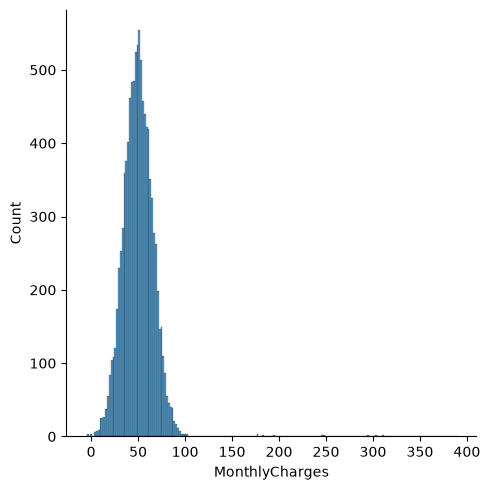

In [166]:
plt.figure()
sns.displot(customer_info["MonthlyCharges"])
plt.show()

In [167]:
customer_info.loc[
    customer_info["MonthlyCharges"] <= 0
]

,CustomerID,Age,Gender,Region,ContractType,MonthlyCharges,SignupDate
4671,CUST_4671,56.0,Male,Rural,Prepaid,-3.89,2020-11-12
5575,CUST_5575,39.0,Female,Suburban,Monthly,-0.46,2023-02-01
6820,CUST_6820,60.0,Male,Urban,Yearly,-3.15,2018-02-09
8567,CUST_8567,36.0,Male,Rural,Prepaid,-6.72,2018-04-17
9403,CUST_9403,19.0,Male,Rural,Monthly,-4.55,2023-05-18


In [168]:
customer_info["MonthlyCharges"].quantile(
    [0, .01, .05, .5, .95, .99, 1]
)

0.00     -6.7200
0.01     14.3598
0.05     25.0290
0.50     50.0000
0.95     75.6425
0.99     89.2814
1.00    390.3000
Name: MonthlyCharges, dtype: float64

### 4.9 Sign Up Date Distribution

In [169]:
print(customer_info["SignupDate"].min())
print(customer_info["SignupDate"].max())

2018-01-01 00:00:00
2023-11-03 00:00:00


In [170]:
print(f"\nCounts by Years:\n{customer_info["SignupDate"].dt.year.value_counts().sort_index()}")
print(f"\nCounts by Months:\n{customer_info["SignupDate"].dt.month.value_counts().sort_index()}")
print(f"\nCounts by Dates:\n{customer_info["SignupDate"].dt.day.value_counts().sort_index()}")
print(f"\nCount by Week Days:\n{customer_info["SignupDate"].dt.day_name().value_counts()}")


Counts by Years:
SignupDate
2018    1909
2019    1851
2020    1808
2021    1857
2022    1842
2023     933
Name: count, dtype: int64

Counts by Months:
SignupDate
1     946
2     891
3     974
4     871
5     975
6     920
7     794
8     771
9     774
10    786
11    730
12    768
Name: count, dtype: int64

Counts by Dates:
SignupDate
1     324
2     343
3     337
4     345
5     338
6     396
7     324
8     339
9     320
10    325
11    322
12    315
13    325
14    350
15    346
16    342
17    338
18    335
19    324
20    340
21    366
22    333
23    318
24    359
25    335
26    332
27    300
28    333
29    299
30    306
31    191
Name: count, dtype: int64

Count by Week Days:
SignupDate
Friday       1501
Sunday       1484
Wednesday    1476
Saturday     1442
Monday       1442
Thursday     1428
Tuesday      1427
Name: count, dtype: int64


## 5. Usage Data Dataset Inspection

### 5.0 Data Sample

In [171]:
print(usage_data.head(15))
print(usage_data.tail(15))

   CustomerID      Month  CallMinutes  DataUsageGB  SMSCount  Complaints
0      CUST_0 2023-01-31       518.12         7.21         9           1
1      CUST_0 2023-02-28       439.79         5.99        35           1
2      CUST_0 2023-03-31       545.06        14.16        14           1
3      CUST_0 2023-04-30       461.78         6.66        40           0
4      CUST_0 2023-05-31       434.82        12.75        26           2
5      CUST_0 2023-06-30       442.07         9.91        24           1
6      CUST_0 2023-07-31       590.26        10.75        13           0
7      CUST_0 2023-08-31       515.54         8.02        32           0
8      CUST_0 2023-09-30       493.27         8.12        41           0
9      CUST_0 2023-10-31       558.78        13.57        39           1
10     CUST_0 2023-11-30       447.32         9.20        17           0
11     CUST_0 2023-12-31       459.99        11.21        10           0
12     CUST_1 2023-01-31       496.82        14.09 

### 5.1 Basic Information

In [172]:
print(f"Column Names: {usage_data.columns}")
print(f"\nDataset Shape: {usage_data.shape}")
print(f"\nDataset Type:\n{usage_data.dtypes}")
print(f"\nNumber of unique values:\n{usage_data.nunique()}")

Column Names: Index(['CustomerID', 'Month', 'CallMinutes', 'DataUsageGB', 'SMSCount', 'Complaints'], dtype='str')

Dataset Shape: (120000, 6)

Dataset Type:
CustomerID                str
Month          datetime64[us]
CallMinutes           float64
DataUsageGB           float64
SMSCount                int64
Complaints              int64
dtype: object

Number of unique values:
CustomerID     10000
Month             12
CallMinutes    44083
DataUsageGB     1963
SMSCount          50
Complaints         7
dtype: int64


### 5.2 Missing Values

In [173]:
print(f"Number of missing values by column:\n{usage_data.isnull().sum()}")

Number of missing values by column:
CustomerID     0
Month          0
CallMinutes    0
DataUsageGB    0
SMSCount       0
Complaints     0
dtype: int64


### 5.3 Duplicate Values

In [174]:
print(f"Number of duplicate rows: {usage_data.duplicated().sum()}")

Number of duplicate rows: 0


### 5.4 Month Distribution

In [175]:
print(usage_data["Month"].min())
print(usage_data["Month"].max())

2023-01-31 00:00:00
2023-12-31 00:00:00


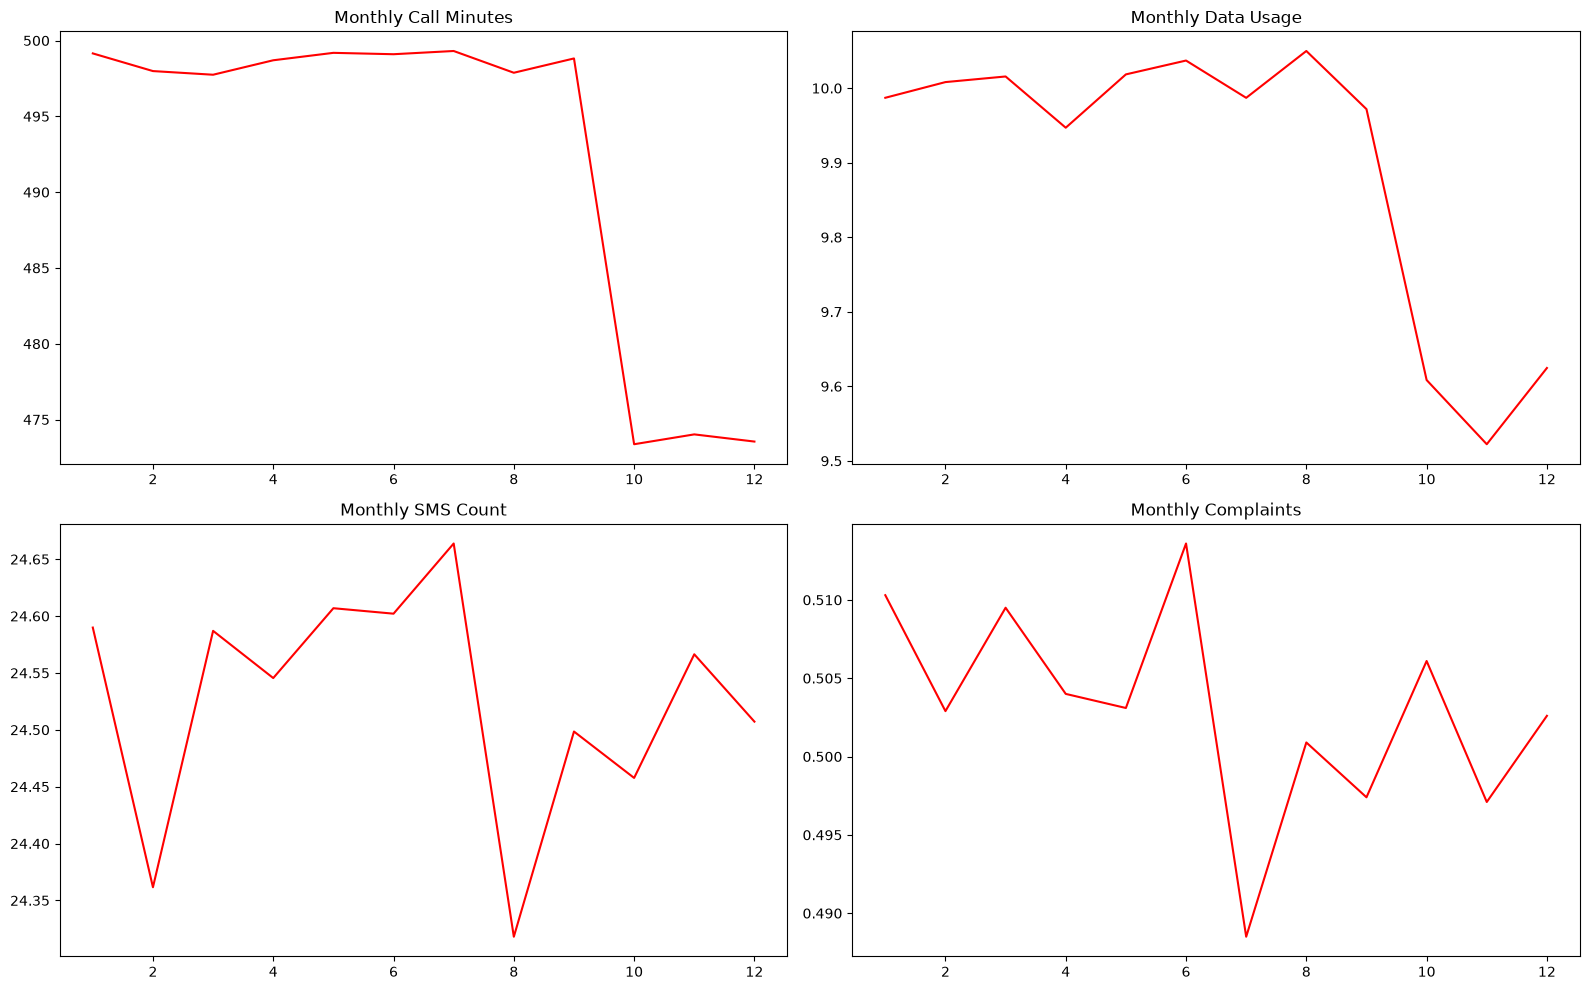

In [176]:
monthly = usage_data.groupby("Month").agg({
    "CallMinutes": "mean",
    "DataUsageGB": "mean",
    "SMSCount": "mean",
    "Complaints": "mean"
})
plt.style.use("default")
fig, ax = plt.subplots(2, 2, figsize=(16, 10))
ax[0,0].plot(monthly.index.month, monthly["CallMinutes"], color="red")
ax[0,1].plot(monthly.index.month, monthly["DataUsageGB"], color="red")
ax[1,0].plot(monthly.index.month, monthly["SMSCount"], color="red")
ax[1,1].plot(monthly.index.month, monthly["Complaints"], color="red")
ax[0, 0].set_title("Monthly Call Minutes")
ax[0, 1].set_title("Monthly Data Usage")
ax[1, 0].set_title("Monthly SMS Count")
ax[1, 1].set_title("Monthly Complaints")
for a in ax.flat:
    a.tick_params(axis="both", colors="black")
plt.tight_layout()
plt.show()

### 5.5 CallMInutes Distribution

In [177]:
print(usage_data["CallMinutes"].describe())

count    120000.000000
mean        492.401958
std         117.443986
min          34.140000
25%         418.450000
50%         494.960000
75%         571.080000
max         914.160000
Name: CallMinutes, dtype: float64


### 5.6 DataUsageGB Distribution

In [178]:
print(usage_data["DataUsageGB"].describe())

count    120000.000000
mean          9.898117
std           3.067815
min           0.000000
25%           7.810000
50%           9.920000
75%          11.980000
max          22.730000
Name: DataUsageGB, dtype: float64


In [179]:
print(usage_data[usage_data["DataUsageGB"] == 0].shape)

(58, 6)


In [180]:
print(usage_data[usage_data["DataUsageGB"] == 0].head())

     CustomerID      Month  CallMinutes  DataUsageGB  SMSCount  Complaints
126     CUST_10 2023-07-31       597.05          0.0        22           1
1151    CUST_95 2023-12-31       287.15          0.0        17           0
1834   CUST_152 2023-11-30       458.29          0.0        39           1
7404   CUST_617 2023-01-31       581.91          0.0         2           0
8784   CUST_732 2023-01-31       577.60          0.0         2           1


### 5.7 SMSCount Distribution

In [181]:
print(usage_data["SMSCount"].describe())

count    120000.000000
mean         24.525392
std          14.423944
min           0.000000
25%          12.000000
50%          25.000000
75%          37.000000
max          49.000000
Name: SMSCount, dtype: float64


In [182]:
print(usage_data[usage_data["SMSCount"] == 0].shape)

(2370, 6)


In [183]:
print(usage_data[usage_data["SMSCount"] == 0].head())

    CustomerID      Month  CallMinutes  DataUsageGB  SMSCount  Complaints
168    CUST_14 2023-01-31       564.55         6.95         0           0
179    CUST_14 2023-12-31       196.47         2.34         0           1
212    CUST_17 2023-09-30       496.13        10.53         0           0
320    CUST_26 2023-09-30       486.13        12.61         0           1
415    CUST_34 2023-08-31       703.83        11.24         0           0


### 5.8 Complaints Distribution

In [184]:
print(usage_data["Complaints"].describe())

count    120000.000000
mean          0.503000
std           0.708763
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max           6.000000
Name: Complaints, dtype: float64


## 6 Merge Data

### 6.0 Basic Information

In [185]:
df = (
    customer_info.
    merge(churn_labels, on="CustomerID").
    merge(usage_data, on="CustomerID")
)
print(f"\nDataset Shape: {df.shape}")
print(f"\nNumber of unique values:\n{df.nunique()}")


Dataset Shape: (122400, 13)

Number of unique values:
CustomerID        10000
Age                  52
Gender                2
Region                3
ContractType          3
MonthlyCharges     4888
SignupDate         1995
Churn                 2
Month                12
CallMinutes       44083
DataUsageGB        1963
SMSCount             50
Complaints            7
dtype: int64


### 6.1 Data Sample

In [186]:
print(df.head(30))
print(df[df["Churn"] == 1].head(10))

   CustomerID   Age  Gender    Region ContractType  MonthlyCharges SignupDate  Churn      Month  CallMinutes  DataUsageGB  SMSCount  Complaints
0      CUST_0   NaN    Male     Urban       Yearly           48.18 2021-03-20      0 2023-01-31       518.12         7.21         9           1
1      CUST_0   NaN    Male     Urban       Yearly           48.18 2021-03-20      0 2023-02-28       439.79         5.99        35           1
2      CUST_0   NaN    Male     Urban       Yearly           48.18 2021-03-20      0 2023-03-31       545.06        14.16        14           1
3      CUST_0   NaN    Male     Urban       Yearly           48.18 2021-03-20      0 2023-04-30       461.78         6.66        40           0
4      CUST_0   NaN    Male     Urban       Yearly           48.18 2021-03-20      0 2023-05-31       434.82        12.75        26           2
5      CUST_0   NaN    Male     Urban       Yearly           48.18 2021-03-20      0 2023-06-30       442.07         9.91        24     

### 6.2 Churn vs Age

In [187]:
print(df.groupby("Churn")["Age"].describe())

         count      mean        std   min   25%   50%   75%   max
Churn                                                            
0      73224.0  43.39020  14.973519  18.0  30.0  43.0  56.0  69.0
1       6180.0  43.83301  14.859735  18.0  31.0  45.0  56.0  69.0


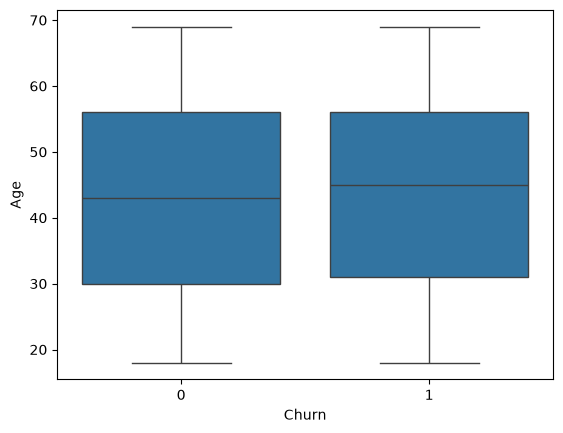

In [188]:
sns.boxplot(data=df, x="Churn", y="Age")
plt.show()

In [189]:
df.assign(
    AgeMissing = df["Age"].isna()
).groupby("AgeMissing")["Churn"].mean()

AgeMissing
False    0.077830
True     0.078705
Name: Churn, dtype: float64

### 6.3 Churn vs Gender

In [190]:
print(df.groupby("Gender")["Churn"].mean())

Gender
Female    0.076803
Male      0.079481
Name: Churn, dtype: float64


<Axes: xlabel='Churn'>

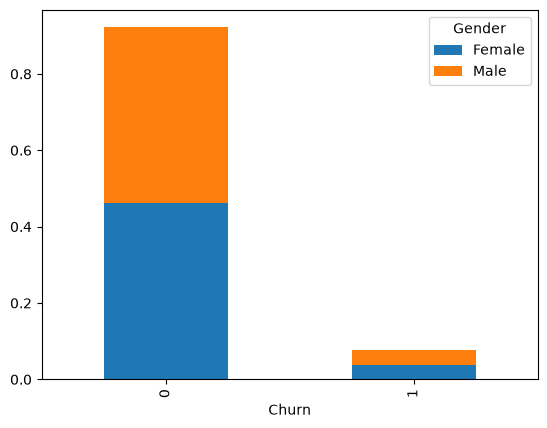

In [191]:
pd.crosstab(df["Churn"], df["Gender"], normalize=True).plot(kind="bar", stacked=True)

### 6.4 Churn vs Region

In [192]:
df.groupby("Region")["Churn"].mean()

Region
Rural       0.072852
Suburban    0.080770
Urban       0.080703
Name: Churn, dtype: float64

<Axes: xlabel='Churn'>

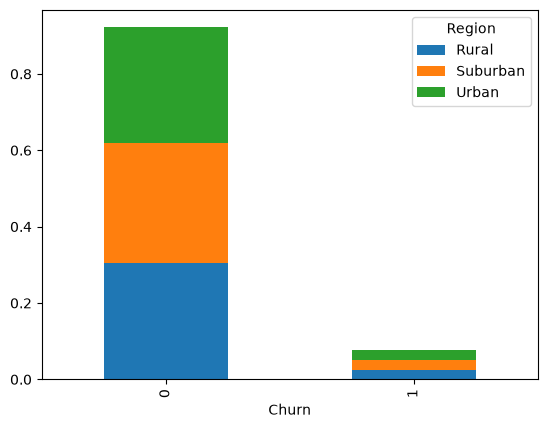

In [193]:
pd.crosstab(df["Churn"], df["Region"], normalize=True).plot(kind="bar", stacked=True)

### 6.5 Churn vs ContractType

In [194]:
df.groupby("ContractType")["Churn"].mean()

ContractType
Monthly    0.075495
Prepaid    0.076026
Yearly     0.087616
Name: Churn, dtype: float64

<Axes: xlabel='ContractType'>

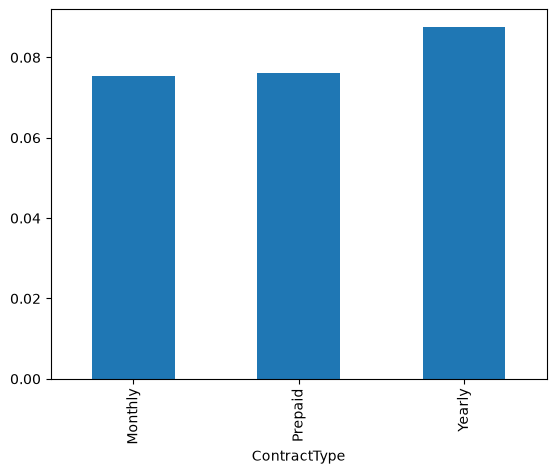

In [195]:
df.groupby("ContractType")["Churn"].mean().plot(kind="bar", stacked=True)

### 6.6 Churn vs MonthlyCharges

In [196]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,112836.0,51.030272,21.384683,-6.72,39.75,50.08,60.53,390.3
1,9564.0,50.156462,21.855326,2.83,40.26,48.63,59.29,318.5


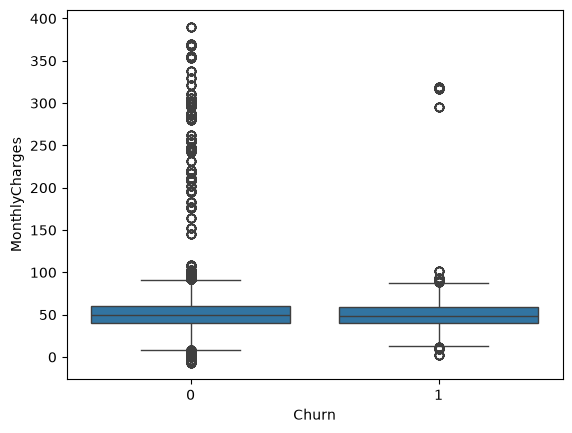

In [197]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.show()

### 6.7 Churn vs Signup Date

In [198]:
df["SignupYear"] = df["SignupDate"].dt.year
df.groupby("SignupYear")["Churn"].mean()

SignupYear
2018    0.079623
2019    0.076715
2020    0.073009
2021    0.082391
2022    0.080347
2023    0.075027
Name: Churn, dtype: float64

<Axes: xlabel='SignupYear'>

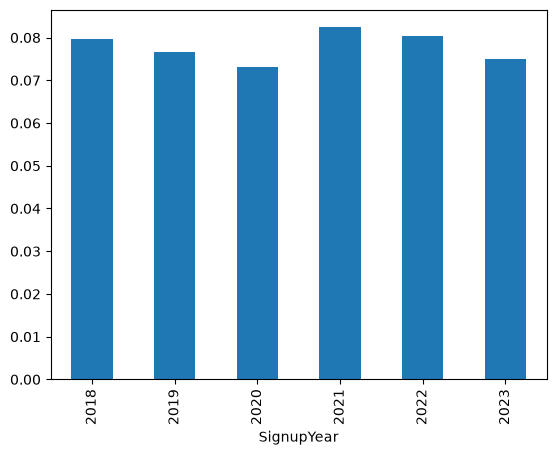

In [199]:
df.groupby("SignupYear")["Churn"].mean().plot(kind="bar", stacked=True)

### 6.8 Churn vs CallMinutes

In [200]:
df.groupby("Churn")["CallMinutes"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,112836.0,492.306918,117.491669,34.14,418.2000,494.895,571.2725,914.16
1,9564.0,494.888162,117.307020,91.27,422.2475,496.780,571.0175,905.18


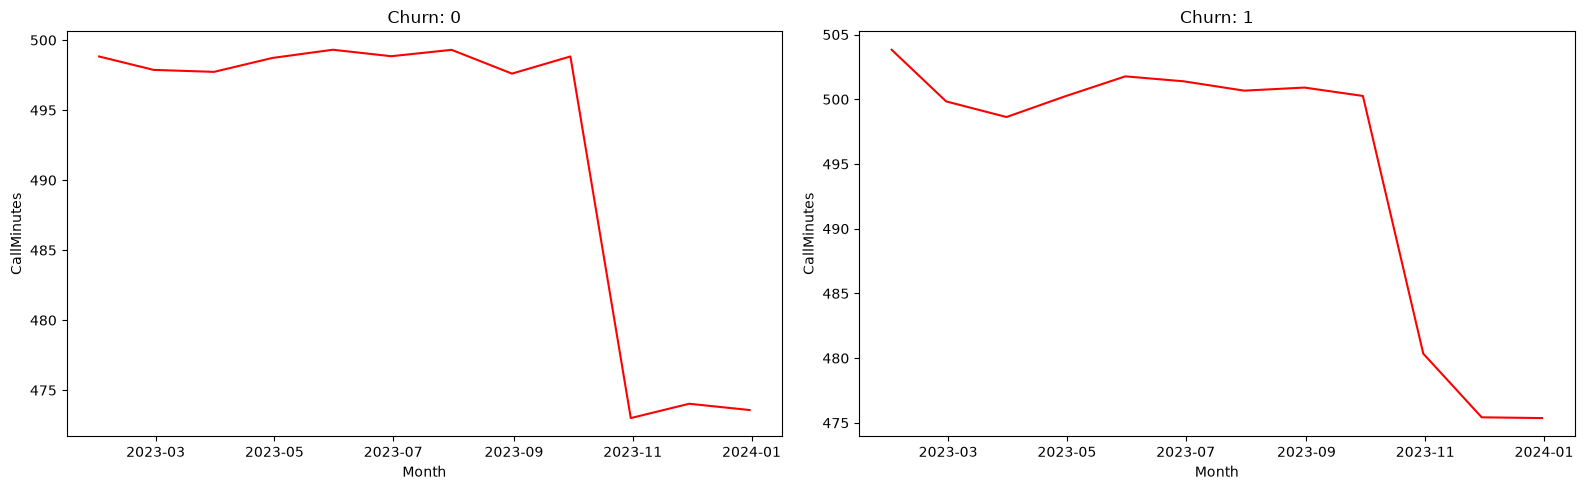

In [201]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

for churn, i in [(0,0), (1,1)]:
    monthly = (
        df[df["Churn"] == churn].
        groupby("Month")["CallMinutes"].
        mean()
    )

    ax[i].plot(monthly.index, monthly.values, color="red")
    ax[i].set_title(f"Churn: {churn}")
    ax[i].set_xlabel("Month")
    ax[i].set_ylabel("CallMinutes")
    ax[i].grid(False)

plt.tight_layout()
plt.show()

### 6.9 Churn vs DataUsageGB

In [202]:
print(df.groupby("Churn")["DataUsageGB"].describe())

          count      mean       std  min   25%   50%    75%    max
Churn                                                             
0      112836.0  9.901206  3.068837  0.0  7.81  9.93  11.98  22.73
1        9564.0  9.874141  3.050244  0.0  7.81  9.87  11.94  22.56


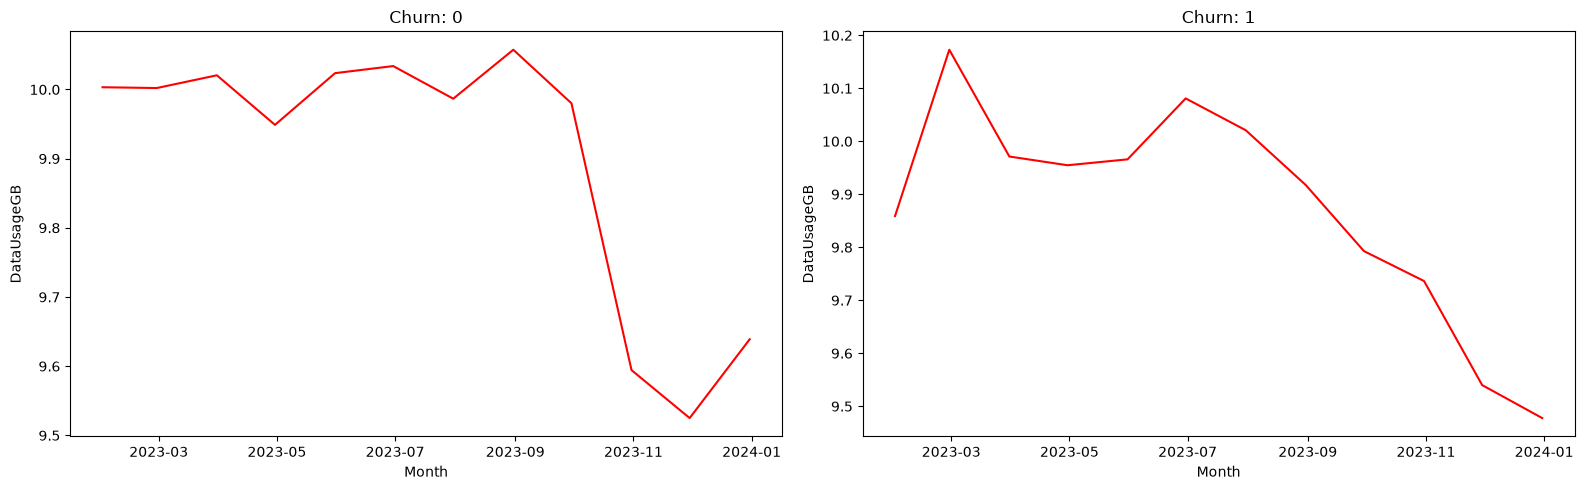

In [203]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
for churn, i in [(0,0), (1,1)]:
    monthly = (
        df[df["Churn"] == churn].
        groupby("Month")["DataUsageGB"].
        mean()
    )

    ax[i].plot(monthly.index, monthly.values, color="red")
    ax[i].set_title(f"Churn: {churn}")
    ax[i].set_xlabel("Month")
    ax[i].set_ylabel("DataUsageGB")
    ax[i].grid(False)

plt.tight_layout()
plt.show()

In [211]:
df[df["Churn"] == 1].groupby("Month")["DataUsageGB"].mean()

Month
2023-01-31     9.858921
2023-02-28    10.172735
2023-03-31     9.971305
2023-04-30     9.954806
2023-05-31     9.965910
2023-06-30    10.080903
2023-07-31    10.020853
2023-08-31     9.917353
2023-09-30     9.792798
2023-10-31     9.736361
2023-11-30     9.540000
2023-12-31     9.477742
Name: DataUsageGB, dtype: float64

In [212]:
df[df["Churn"] == 0].groupby("Month")["DataUsageGB"].mean()

Month
2023-01-31    10.003226
2023-02-28    10.002073
2023-03-31    10.020506
2023-04-30     9.948862
2023-05-31    10.023581
2023-06-30    10.033823
2023-07-31     9.986666
2023-08-31    10.057414
2023-09-30     9.980015
2023-10-31     9.594336
2023-11-30     9.525007
2023-12-31     9.638968
Name: DataUsageGB, dtype: float64

### 6.10 Churn vs SMSCount

In [204]:
df.groupby("Churn")["SMSCount"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,112836.0,24.499424,14.427984,0.0,12.0,25.0,37.0,49.0
1,9564.0,24.872438,14.381618,0.0,12.0,25.0,37.0,49.0


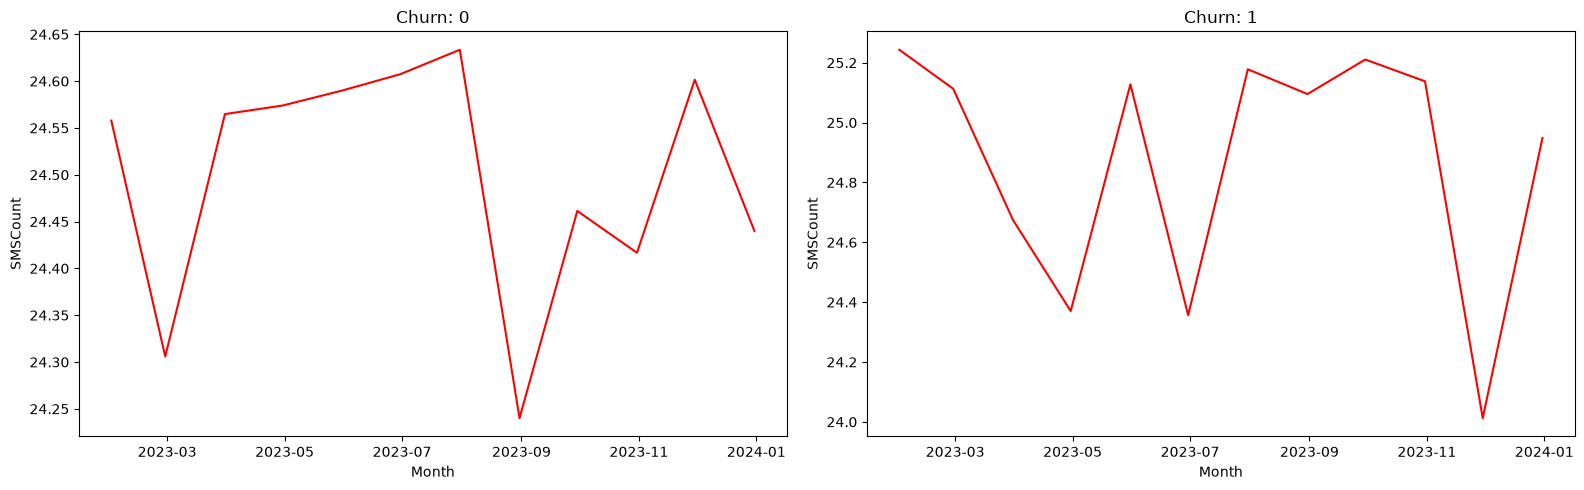

In [205]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
for churn, i in [(0,0), (1,1)]:
    monthly = (
        df[df["Churn"] == churn].
        groupby("Month")["SMSCount"].
        mean()
    )

    ax[i].plot(monthly.index, monthly.values, color="red")
    ax[i].set_title(f"Churn: {churn}")
    ax[i].set_xlabel("Month")
    ax[i].set_ylabel("SMSCount")
    ax[i].grid(False)

plt.tight_layout()
plt.show()

### 6.11 Churn vs Complaints

In [206]:
df.groupby("Churn")["Complaints"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
0,112836.0,0.502216,0.708640,0.0,0.0,0.0,1.0,6.0
1,9564.0,0.513384,0.710484,0.0,0.0,0.0,1.0,5.0


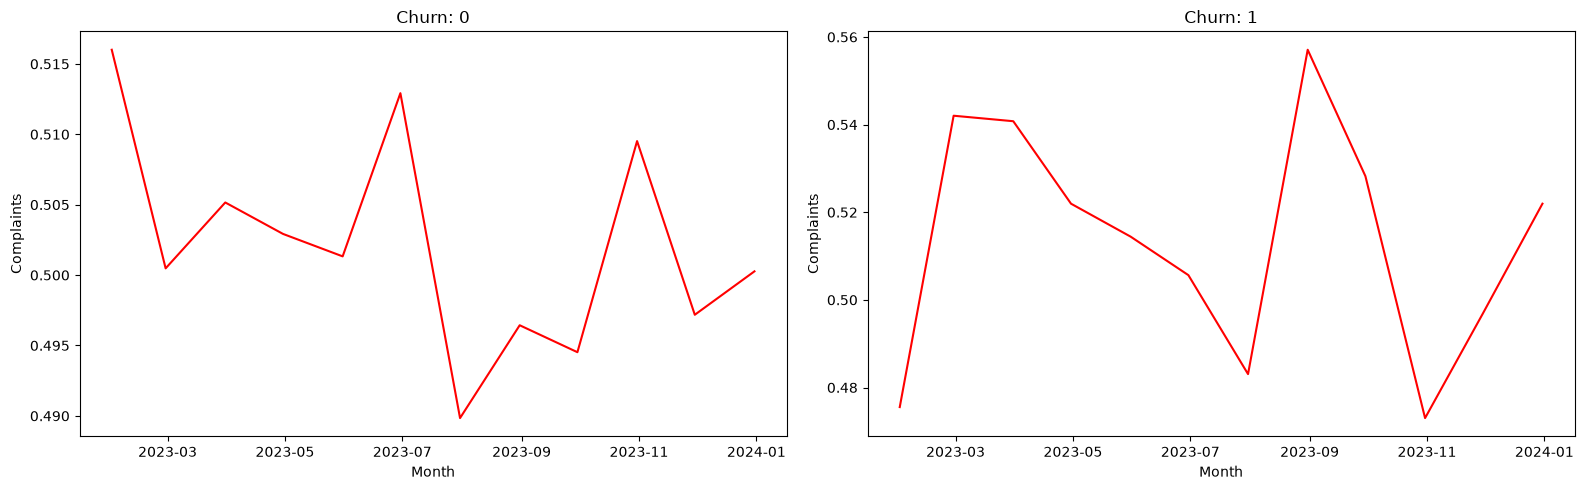

In [207]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
for churn, i in [(0,0), (1,1)]:
    monthly = (
        df[df["Churn"] == churn].
        groupby("Month")["Complaints"].
        mean()
    )

    ax[i].plot(monthly.index, monthly.values, color="red")
    ax[i].set_title(f"Churn: {churn}")
    ax[i].set_xlabel("Month")
    ax[i].set_ylabel("Complaints")
    ax[i].grid(False)

plt.tight_layout()
plt.show()

# EDA Summary & Conclusion

## Dataset Overview

The analysis combines three datasets: `churn_labels.csv`, `customer_info.csv`, and `usage_data.csv`, containing information on **10,000 unique customers**. The churn target is imbalanced, with **7.86% of customers having churned and 92.14% remaining active**. This class imbalance should be considered in subsequent statistical analysis and predictive modeling.

## Data Quality Findings

Several data-quality issues were identified during the exploration. The `customer_info` dataset contains **195 duplicate rows involving 200 duplicate CustomerIDs**. However, all CustomerIDs are still represented after merging the datasets, so the duplicates did not result in customer records being lost.

`MonthlyCharges` contains **5 negative values**, which are invalid for a charge variable and should be addressed during preprocessing. The variable is also strongly right-skewed (skewness ≈ **5.58**), indicating that most customers have relatively lower charges while a small number have substantially higher values.

Missing values are also present in `Age`. The analysis did not reveal a visible difference in churn behavior between customers with and without an observed age value.

## Churn-Related Findings

The exploratory analysis does not show a strong visible relationship between churn and most demographic variables. **Gender** has very similar churn rates for females (**7.68%**) and males (**7.95%**), while **Region** also shows relatively similar rates across Rural (**7.29%**), Suburban (**8.08%**), and Urban (**8.07%**) customers.

**ContractType** shows some variation, with Yearly contracts having an observed churn rate of **8.76%**, compared with **7.55%** for Monthly and **7.60%** for Prepaid contracts. However, the differences are relatively small, so ContractType should be treated as a potentially useful feature rather than a strong standalone explanation of churn.

**MonthlyCharges** shows similar central distributions between churned and non-churned customers. The greater number of high-value observations among non-churned customers should not be interpreted directly as a churn pattern because the dataset is strongly imbalanced.

## Customer Usage Behavior

The usage variables provide some additional behavioral information. **CallMinutes** are generally slightly lower for churned customers across the observed months, but the overall distributions remain very similar, suggesting only a weak visible difference.

**SMSCount** and **Complaints** do not show clear differences between churn groups. Their monthly patterns and overall levels are relatively similar for churned and non-churned customers.

The most notable behavioral pattern appears in **DataUsageGB**. Although the overall average usage is similar between the two groups, the monthly trends differ during the latter part of the observation period. Data usage for customers labeled as churned shows a noticeable downward trend during the last six months, while usage among non-churned customers remains comparatively stable.

This is the clearest behavioral difference identified in the EDA. However, it should be interpreted as an **association rather than evidence of causation**.

## Important Temporal Limitation

The usage data covers **January 2023 through December 2023**, but the dataset does not contain an actual churn date. Therefore, it is not possible to determine whether a change in usage occurred immediately before a customer churned.

Consequently, the downward DataUsageGB pattern should not be described as confirmed *pre-churn behavior*. It is an observed difference between customers labeled as churned and non-churned within the available observation period.

## Overall Conclusion

Overall, the EDA suggests that **most demographic and basic usage variables do not show strong standalone differences between churned and non-churned customers**. Gender, Region, Age, SMS usage, Complaints, and MonthlyCharges show substantial overlap between the two groups, while ContractType and CallMinutes show relatively small differences.

The analysis also identifies important preprocessing requirements, including handling duplicate customer records, invalid negative charges, missing age values, skewed monetary values, and the substantial class imbalance in the churn target.

The next stage should therefore focus on **data cleaning, customer-level feature engineering, statistical analysis, and baseline churn modeling**. In particular, monthly usage data can be transformed into customer-level features such as average usage, recent usage, usage variability, and changes in usage over time. These features can then be evaluated to determine whether the patterns observed during EDA provide meaningful predictive information about churn.
